# Notebook 01

## Bronze Hazard Layer

### Objective

Transform raw ERA5 NetCDF rainfall data into a standardized analytical dataset while preserving the original scientific meaning of the observations.

Project:

India Flood Risk Platform

Author:

Suhana Gupta

# 1. Imports

# 2. Project Paths

# 3. Load ERA5 Dataset

# 4. Explore Dataset

# 5. Metadata Inspection

# 6. Convert NetCDF to DataFrame

# 7. Unit Conversion

# 8. Data Quality Checks

# 9. Export Bronze Layer

# 10. Engineering Summary

## Expected Deliverables

By the end of this notebook, we will have:

- Loaded the ERA5 NetCDF dataset.
- Explored the dataset structure and metadata.
- Converted rainfall units from metres to millimetres.
- Converted the NetCDF grid into a tabular DataFrame.
- Performed initial data quality checks.
- Exported the Bronze Layer as a Parquet dataset.

**Output**

`data/bronze/bronze_rainfall_2023.parquet`

In [1]:
# ============================================================
# Notebook 01 : Bronze Hazard Layer
# India Flood Risk Platform
# ============================================================

# Standard Library
from pathlib import Path

# Data Handling
import pandas as pd
import numpy as np

# NetCDF Handling
import xarray as xr

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"

BRONZE_DIR = DATA_DIR / "bronze"

ERA5_FILE = (
    RAW_DIR
    / "era5"
    / "ERA5_India_TotalPrecipitation_2023.nc"
)

print("Project Root :", PROJECT_ROOT)
print("ERA5 File :", ERA5_FILE)

Project Root : d:\Work\Projects\India_Flood_Risk_Platform
ERA5 File : d:\Work\Projects\India_Flood_Risk_Platform\data\raw\era5\ERA5_India_TotalPrecipitation_2023.nc


In [3]:
# ============================================================
# Verify ERA5 File
# ============================================================

print("File Exists :", ERA5_FILE.exists())

File Exists : True


In [4]:
# ============================================================
# Load ERA5 Dataset
# ============================================================

ds = xr.open_dataset(ERA5_FILE)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
ds

<xarray.Dataset> Size: 23MB
Dimensions:     (valid_time: 365, latitude: 129, longitude: 121)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2023-01-01 ... 2023-12-31
  * latitude    (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude   (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 23MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-07T17:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
# ============================================================
# Dataset Dimensions
# ============================================================

print(ds.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 365, 'latitude': 129, 'longitude': 121})


In [7]:
ds.sizes

Frozen({'valid_time': 365, 'latitude': 129, 'longitude': 121})

In [8]:
ds.coords

Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2023-01-01 ... 2023-12-31
  * latitude    (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude   (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number      int64 8B ...

In [9]:
print(ds.latitude.min().values)
print(ds.latitude.max().values)

6.0
38.0


In [11]:
print(ds.longitude.min().values)
print(ds.longitude.max().values)

68.0
98.0


In [12]:
print(ds.valid_time.min().values)
print(ds.valid_time.max().values)

2023-01-01T00:00:00.000000000
2023-12-31T00:00:00.000000000


In [14]:
ds.data_vars

Data variables:
    tp       (valid_time, latitude, longitude) float32 23MB ...

In [15]:
tp = ds["tp"]

tp

<xarray.DataArray 'tp' (valid_time: 365, latitude: 129, longitude: 121)> Size: 23MB
[5697285 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2023-01-01 ... 2023-12-31
  * latitude    (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude   (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      15609
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [16]:
# ============================================================
# Metadata Inspection
# ============================================================

tp.attrs

{'GRIB_paramId': np.int64(228),
 'GRIB_dataType': 'fc',
 'GRIB_numberOfPoints': np.int64(15609),
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': np.int64(1),
 'GRIB_stepType': 'accum',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': np.int64(0),
 'GRIB_NV': np.int64(0),
 'GRIB_Nx': np.int64(121),
 'GRIB_Ny': np.int64(129),
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 'tp',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_iScansNegatively': np.int64(0),
 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_jPointsAreConsecutive': np.int64(0),
 'GRIB_jScansPositively': np.int64(0),
 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(38.0),
 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(6.0),
 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(68.0),
 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(98.0),
 'GRIB_missingValue': np.float64(3.4028234663852886e+38),
 'GRIB_name':

In [17]:
print("Minimum:", tp.min().values)
print("Maximum:", tp.max().values)
print("Mean:", tp.mean().values)
print("Standard Deviation:", tp.std().values)

Minimum: 0.0
Maximum: 0.40134764
Mean: 0.003557643
Standard Deviation: 0.00902162


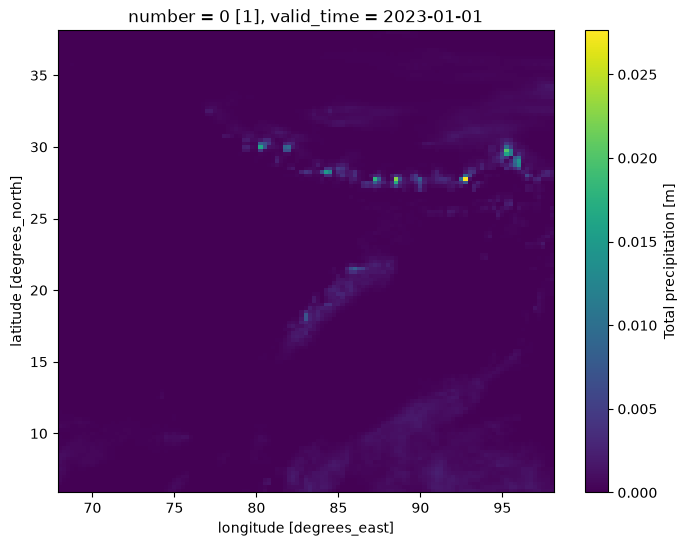

In [19]:
tp.isel(valid_time=0).plot(figsize=(8,6));

In [21]:
# ============================================================
# Convert NetCDF to DataFrame
# ============================================================

df = tp.to_dataframe().reset_index()

df.head()

,valid_time,latitude,longitude,number,tp
0,2023-01-01,38.0,68.00,0,0.0
1,2023-01-01,38.0,68.25,0,0.0
2,2023-01-01,38.0,68.50,0,0.0
3,2023-01-01,38.0,68.75,0,0.0
4,2023-01-01,38.0,69.00,0,0.0


In [22]:
df.rename(
    columns={
        "valid_time": "date",
        "tp": "rainfall_m"
    },
    inplace=True
)

df.head()

,date,latitude,longitude,number,rainfall_m
0,2023-01-01,38.0,68.00,0,0.0
1,2023-01-01,38.0,68.25,0,0.0
2,2023-01-01,38.0,68.50,0,0.0
3,2023-01-01,38.0,68.75,0,0.0
4,2023-01-01,38.0,69.00,0,0.0


In [23]:
df["rainfall_mm"] = df["rainfall_m"] * 1000

df.head()

,date,latitude,longitude,number,rainfall_m,rainfall_mm
0,2023-01-01,38.0,68.00,0,0.0,0.0
1,2023-01-01,38.0,68.25,0,0.0,0.0
2,2023-01-01,38.0,68.50,0,0.0,0.0
3,2023-01-01,38.0,68.75,0,0.0,0.0
4,2023-01-01,38.0,69.00,0,0.0,0.0


In [24]:
print("Shape:", df.shape)

print("\nMissing Values")
print(df.isna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

Shape: (5697285, 6)

Missing Values
date           0
latitude       0
longitude      0
number         0
rainfall_m     0
rainfall_mm    0
dtype: int64

Duplicate Rows: 0

Data Types
date           datetime64[ns]
latitude              float64
longitude             float64
number                  int64
rainfall_m            float32
rainfall_mm           float32
dtype: object


In [25]:
df["rainfall_mm"].describe()

count    5.697285e+06
mean     3.557643e+00
std      9.021621e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.822876e-01
75%      2.918720e+00
max      4.013476e+02
Name: rainfall_mm, dtype: float64

In [26]:
# ============================================================
# Export Bronze Layer
# ============================================================

output_file = BRONZE_DIR / "bronze_rainfall_2023.parquet"

df.to_parquet(
    output_file,
    index=False
)

print("Bronze Layer exported successfully!")
print(output_file)

Bronze Layer exported successfully!
d:\Work\Projects\India_Flood_Risk_Platform\data\bronze\bronze_rainfall_2023.parquet


In [27]:
import pandas as pd

bronze = pd.read_parquet(
    BRONZE_DIR / "bronze_rainfall_2023.parquet"
)

bronze.head()

,date,latitude,longitude,number,rainfall_m,rainfall_mm
0,2023-01-01,38.0,68.00,0,0.0,0.0
1,2023-01-01,38.0,68.25,0,0.0,0.0
2,2023-01-01,38.0,68.50,0,0.0,0.0
3,2023-01-01,38.0,68.75,0,0.0,0.0
4,2023-01-01,38.0,69.00,0,0.0,0.0


In [28]:
bronze.shape

(5697285, 6)

In [30]:
bronze.info()

<class 'pandas.DataFrame'>
RangeIndex: 5697285 entries, 0 to 5697284
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   latitude     float64       
 2   longitude    float64       
 3   number       int64         
 4   rainfall_m   float32       
 5   rainfall_mm  float32       
dtypes: datetime64[ns](1), float32(2), float64(2), int64(1)
memory usage: 217.3 MB


In [31]:
bronze.describe()

,date,latitude,longitude,number,rainfall_m,rainfall_mm
count,5697285,5.697285e+06,5.697285e+06,5697285.0,5.697285e+06,5.697285e+06
mean,2023-07-01 23:59:59.999994880,2.200000e+01,8.300000e+01,0.0,3.557643e-03,3.557643e+00
min,2023-01-01 00:00:00,6.000000e+00,6.800000e+01,0.0,0.000000e+00,0.000000e+00
25%,2023-04-02 00:00:00,1.400000e+01,7.550000e+01,0.0,0.000000e+00,0.000000e+00
50%,2023-07-02 00:00:00,2.200000e+01,8.300000e+01,0.0,2.822876e-04,2.822876e-01
75%,2023-10-01 00:00:00,3.000000e+01,9.050000e+01,0.0,2.918720e-03,2.918720e+00
max,2023-12-31 00:00:00,3.800000e+01,9.800000e+01,0.0,4.013476e-01,4.013476e+02
std,NaN,9.309494e+00,8.732125e+00,0.0,9.021621e-03,9.021621e+00


# 11. Engineering Summary

## Objective

Transform raw ERA5 NetCDF rainfall data into a standardized Bronze Layer analytical dataset.

## Input

- Dataset: ERA5 Daily Total Precipitation
- Format: NetCDF (.nc)
- Year: 2023
- Spatial Resolution: 0.25°
- Coverage: India (68°E–98°E, 6°N–38°N)

## Processing Steps

1. Loaded ERA5 NetCDF dataset.
2. Validated dataset dimensions and metadata.
3. Inspected coordinates and rainfall variable.
4. Converted NetCDF to a tabular DataFrame.
5. Converted rainfall units from metres to millimetres.
6. Performed quality checks.
7. Exported Bronze Layer in Parquet format.

## Output

data/bronze/bronze_rainfall_2023.parquet


In [33]:
print("="*60)
print("BRONZE LAYER SUMMARY")
print("="*60)

print(f"Rows              : {len(df):,}")
print(f"Columns           : {df.shape[1]}")
print(f"Date Range        : {df['date'].min()} to {df['date'].max()}")
print(f"Latitude Range    : {df['latitude'].min()} to {df['latitude'].max()}")
print(f"Longitude Range   : {df['longitude'].min()} to {df['longitude'].max()}")
print(f"Maximum Rainfall  : {df['rainfall_mm'].max():.2f} mm")
print(f"Average Rainfall  : {df['rainfall_mm'].mean():.2f} mm")

print("\nOutput File")
print(output_file)

BRONZE LAYER SUMMARY
Rows              : 5,697,285
Columns           : 6
Date Range        : 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Latitude Range    : 6.0 to 38.0
Longitude Range   : 68.0 to 98.0
Maximum Rainfall  : 401.35 mm
Average Rainfall  : 3.56 mm

Output File
d:\Work\Projects\India_Flood_Risk_Platform\data\bronze\bronze_rainfall_2023.parquet
